## ✅ Cell 1 — Install Dependencies

In [ ]:
# Install required libraries
!pip install transformers==4.40.0 scikit-learn seaborn matplotlib torch -q
print('✅ All libraries installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 73.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
✅ All libraries installed!


In [ ]:
!pip install transformers==4.40.0 -q --force-reinstall
print('✅ Fixed! Now restart runtime.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.5/801.5 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.2/507.2 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.7/153.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## ✅ Cell 2 — Imports & GPU Check

In [1]:
!pip uninstall -y numpy scipy scikit-learn
!pip install numpy==1.26.4 scipy==1.11.4 scikit-learn==1.3.2

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 78.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spopt 0.7.0 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is inc

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

# ── Check GPU ──────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  No GPU detected! Go to Runtime → Change runtime type → T4 GPU')

✅ Device: cuda
   GPU: Tesla T4


## ✅ Cell 3 — Upload & Load Dataset

In [2]:
from google.colab import files

print('📂 Upload your kannada_news_headlines.csv file:')
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]

df = pd.read_csv(CSV_PATH)

# ── Basic Validation ───────────────────────────────────────────────────
assert 'headline' in df.columns and 'label' in df.columns, \
    "❌ CSV must have 'headline' and 'label' columns!"

df = df.dropna(subset=['headline', 'label'])
df['headline'] = df['headline'].astype(str).str.strip()
df = df.drop_duplicates(subset='headline').reset_index(drop=True)
df['label'] = df['label'].astype(int)

label_names = {0: 'Neutral', 1: 'Offensive', 2: 'Biased'}

print(f'\n✅ Dataset loaded: {df.shape[0]} rows')
print('\n📊 Label Distribution (Before Balancing):')
for k, v in df['label'].value_counts().sort_index().items():
    print(f'  {k} — {label_names[k]}: {v} samples')
df.head(10)

📂 Upload your kannada_news_headlines.csv file:


Saving kannada_news_headlines.csv to kannada_news_headlines.csv

✅ Dataset loaded: 753 rows

📊 Label Distribution (Before Balancing):
  0 — Neutral: 351 samples
  1 — Offensive: 276 samples
  2 — Biased: 126 samples


,id,headline,label
0,1,ವೈಭವ್ ಅಬ್ಬರಕ್ಕೆ ತಲೆಬಾಗಿದ ಇಂಗ್ಲೆಂಡ್ ಭಾರತಕ್ಕೆ ಚಾ...,0
1,2,ಮೆಟ್ರೊ ಟಿಕೆಟ್ ದರ ಏರಿಕೆ ಕೊನೆಗೂ ಮೌನಮುರಿದ ಸಿದ್ದರಾ...,0
2,3,ಶಿಕಾರಿಪುರದಲ್ಲಿ ನಾಡ ಬಂದೂಕು ತಯಾರಿಕಾ ಜಾಲ ಪತ್ತೆ,0
3,4,ಪಾಕಿಸ್ತಾನದಲ್ಲಿ ಮುಸ್ಲಿಮರ ಮಸೀದಿ ಮೇಲೂ ಬಾಂಬ್ ದಾಳಿ ...,1
4,5,ಟಿ20 ವಿಶ್ವಕಪ್ ತಂಡಗಳು ಮತ್ತು ವೇಳಾಪಟ್ಟಿ ವಿವರ,0
5,6,ಬೆಂಗಳೂರು ಚಿತ್ರೋತ್ಸವ ಲಾಸ್ಟ್ ಲ್ಯಾಂಡ್ಗೆ ಅತ್ಯುತ್ತಮ...,0
6,7,ಸಂತ್ರಸ್ತರ ಸೂರಿಗಾಗಿ ಕೊಟ್ಟ ಜಾಗದಲ್ಲಿ ಮಸೀದಿ ನಿರ್ಮಾ...,1
7,8,ಬಡವರ ಬಾದಾಮಿ ಬೆಳೆದ ರೈತರಿಗೀಗ ಸಂಕಷ್ಟ ದಲ್ಲಾಳಿ ಮೋಸ,1
8,9,ಘೂಸ್ಖೋರ್ ಪಂಡತ್ ವಿವಾದ ಟೀಸರ್ ಡಿಲೀಟ್ ಮಾಡಿದ ನೆಟ್ಫ್...,0
9,10,ಯುವ ಆಲ್ರೌಂಡರ್ ಔಟ್ ಭಾರತ ತಂಡಕ್ಕೆ ಅನುಭವಿ ವೇಗಿ ಇನ್,0


## ✅ Cell 4 — Visualize Class Distribution

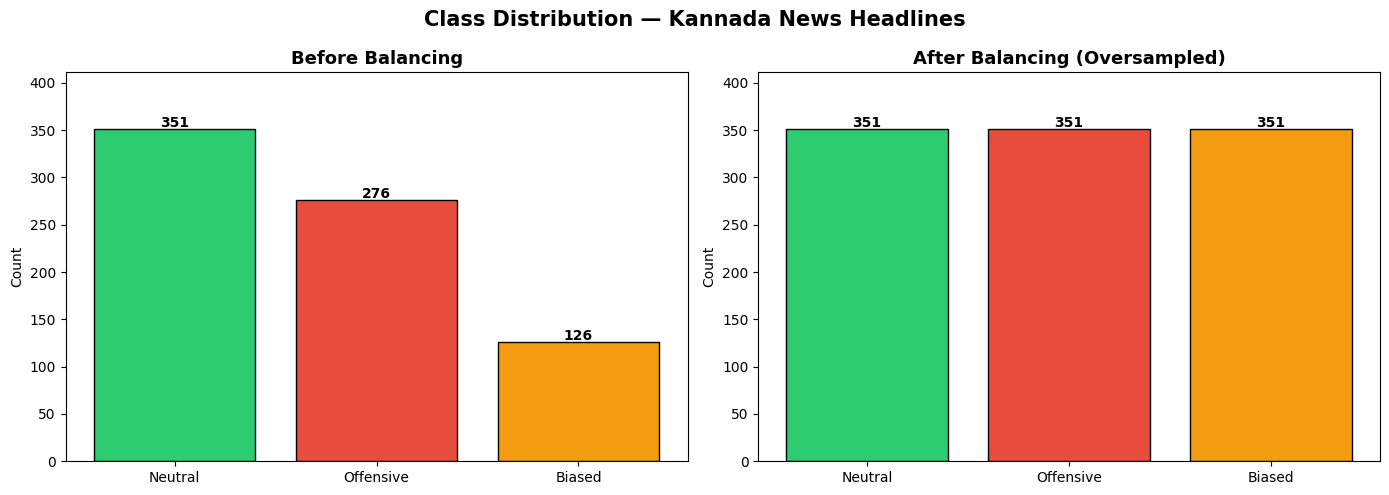


📌 Target samples per class : 351
📌 Total after balancing     : 1053


In [3]:
colors = ['#2ecc71', '#e74c3c', '#f39c12']
label_counts_before = df['label'].value_counts().sort_index()
target_count = int(label_counts_before.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution — Kannada News Headlines', fontsize=15, fontweight='bold')

# Before
bars0 = axes[0].bar(
    [label_names[i] for i in range(3)],
    [label_counts_before.get(i, 0) for i in range(3)],
    color=colors, edgecolor='black'
)
axes[0].set_title('Before Balancing', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar in bars0:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(int(bar.get_height())), ha='center', fontweight='bold')
axes[0].set_ylim(0, max(label_counts_before.values) + 60)

# After
bars1 = axes[1].bar(
    [label_names[i] for i in range(3)],
    [target_count] * 3,
    color=colors, edgecolor='black'
)
axes[1].set_title('After Balancing (Oversampled)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(int(bar.get_height())), ha='center', fontweight='bold')
axes[1].set_ylim(0, target_count + 60)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 Target samples per class : {target_count}')
print(f'📌 Total after balancing     : {target_count * 3}')

## ✅ Cell 5 — Oversample & Split Dataset

In [4]:
def oversample_dataframe(df, label_col='label'):
    """
    Oversample ALL minority classes to match the majority class.
    Returns a balanced, shuffled DataFrame.
    """
    max_count = df[label_col].value_counts().max()
    balanced_dfs = []
    for label in sorted(df[label_col].unique()):
        label_df = df[df[label_col] == label]
        if len(label_df) < max_count:
            label_df = resample(
                label_df,
                replace=True,
                n_samples=max_count,
                random_state=42
            )
        balanced_dfs.append(label_df)
    return pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)


# ── Split ORIGINAL data → train_raw + test ─────────────────────────────
# Test set uses ORIGINAL distribution (real-world evaluation)
train_raw, test_df = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df['label']
)

# ── Balance ONLY the training portion ─────────────────────────────────
train_balanced = oversample_dataframe(train_raw)

# ── Split balanced train → train + val ────────────────────────────────
train_df, val_df = train_test_split(
    train_balanced, test_size=0.15, random_state=42,
    stratify=train_balanced['label']
)

print('✅ Dataset Split Summary:')
print(f'\n  Train (balanced): {len(train_df)} samples')
print('  ', dict(sorted(Counter(train_df["label"].tolist()).items())))
print(f'\n  Val   (balanced): {len(val_df)} samples')
print('  ', dict(sorted(Counter(val_df["label"].tolist()).items())))
print(f'\n  Test  (original): {len(test_df)} samples  ← real-world distribution')
print('  ', dict(sorted(Counter(test_df["label"].tolist()).items())))

✅ Dataset Split Summary:

  Train (balanced): 759 samples
   {0: 253, 1: 253, 2: 253}

  Val   (balanced): 135 samples
   {0: 45, 1: 45, 2: 45}

  Test  (original): 113 samples  ← real-world distribution
   {0: 53, 1: 41, 2: 19}


## ✅ Cell 6 — Load MuRIL Tokenizer & Build Dataset

In [5]:
# ── Config ─────────────────────────────────────────────────────────────
MODEL_NAME = 'google/muril-base-cased'
MAX_LEN    = 128
BATCH_SIZE = 16

# ── Load MuRIL Tokenizer ───────────────────────────────────────────────
print(f'Loading MuRIL tokenizer: {MODEL_NAME} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('✅ MuRIL Tokenizer loaded!')

# ── Dataset Class ──────────────────────────────────────────────────────
class KannadaDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.headlines = dataframe['headline'].tolist()
        self.labels    = dataframe['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.headlines)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.headlines[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ── DataLoaders ────────────────────────────────────────────────────────
train_dataset = KannadaDataset(train_df, tokenizer, MAX_LEN)
val_dataset   = KannadaDataset(val_df,   tokenizer, MAX_LEN)
test_dataset  = KannadaDataset(test_df,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'\n✅ DataLoaders created!')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val   batches : {len(val_loader)}')
print(f'   Test  batches : {len(test_loader)}')

Loading MuRIL tokenizer: google/muril-base-cased ...


config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

✅ MuRIL Tokenizer loaded!

✅ DataLoaders created!
   Train batches : 48
   Val   batches : 9
   Test  batches : 8


## ✅ Cell 7 — Load MuRIL Model

In [6]:
print(f'Loading MuRIL model: {MODEL_NAME} ...')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    output_attentions=False,
    output_hidden_states=False
)
model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n✅ MuRIL model loaded on {device}')
print(f'   Total params     : {total:,}')
print(f'   Trainable params : {trainable:,}')
print(f'\n📌 MuRIL is Google\'s BERT for 17 Indian Languages including Kannada!')
print(f'   Trained on: Wikipedia + News + Web crawls → perfect for news classification')

Loading MuRIL model: google/muril-base-cased ...


pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expe


✅ MuRIL model loaded on cuda
   Total params     : 237,558,531
   Trainable params : 237,558,531

📌 MuRIL is Google's BERT for 17 Indian Languages including Kannada!
   Trained on: Wikipedia + News + Web crawls → perfect for news classification


## ✅ Cell 8 — Class Weights, Optimizer, Scheduler, Loss

In [7]:
# ── Hyperparameters ────────────────────────────────────────────────────
EPOCHS       = 20
LR           = 3e-5     # MuRIL works better with 3e-5 vs mBERT's 2e-5
WARMUP_RATIO = 0.1
PATIENCE     = 5        # Increased patience for 20 epochs
WEIGHT_DECAY = 0.01

# ── Class Weights: penalize Offensive mistakes more ────────────────────
# Offensive (class 1) is hardest to detect → give it 3x weight
class_weights_tensor = torch.tensor([1.0, 3.0, 1.5], dtype=torch.float).to(device)
# Neutral=1.0  |  Offensive=3.0 (hardest)  |  Biased=1.5

# ── Optimizer ─────────────────────────────────────────────────────────
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ── Scheduler: linear warmup then decay ───────────────────────────────
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# ── Loss with class weights ────────────────────────────────────────────
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

print('✅ Training setup complete!')
print(f'   Epochs         : {EPOCHS}')
print(f'   Learning Rate  : {LR}')
print(f'   Early Stopping : patience={PATIENCE}')
print(f'   Total Steps    : {total_steps:,}')
print(f'   Warmup Steps   : {warmup_steps:,}')
print(f'   Class Weights  : Neutral=1.0 | Offensive=3.0 | Biased=1.5')
print(f'   Batch Size     : {BATCH_SIZE}')

✅ Training setup complete!
   Epochs         : 20
   Learning Rate  : 3e-05
   Early Stopping : patience=5
   Total Steps    : 960
   Warmup Steps   : 96
   Class Weights  : Neutral=1.0 | Offensive=3.0 | Biased=1.5
   Batch Size     : 16


## ✅ Cell 9 — Training & Evaluation Functions

In [8]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_b       = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels_b)
        loss.backward()

        # Gradient clipping prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels_b).sum().item()
        total   += len(labels_b)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_b       = batch['label'].to(device)

            outputs    = model(input_ids=input_ids, attention_mask=attention_mask)
            loss       = loss_fn(outputs.logits, labels_b)
            total_loss += loss.item()

            preds = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_b.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader), acc, f1, all_preds, all_labels


print('✅ Training and evaluation functions ready!')

✅ Training and evaluation functions ready!


In [9]:
from google.colab import drive
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Mount Google Drive
drive.mount('/content/drive')

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_DIR = '/content/drive/MyDrive/muril_kannada_news'  # where you saved it

tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
model     = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(device)
model.eval()
print('✅ Model loaded from Drive! Ready to use.')

Mounted at /content/drive


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

✅ Model loaded from Drive! Ready to use.


## ✅ Cell 10 — Train for 20 Epochs (with Early Stopping)

In [10]:
best_model_path = '/content/best_muril_kannada.pt'

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : [],
    'val_f1'    : []
}

best_val_f1      = 0.0
patience_counter = 0

print('=' * 65)
print('   🚀 TRAINING — Kannada News Trust Analyser (MuRIL)')
print(f'   Epochs: {EPOCHS} | LR: {LR} | Batch: {BATCH_SIZE} | Device: {device}')
print('=' * 65)

for epoch in range(1, EPOCHS + 1):
    print(f'\n🔄 Epoch {epoch}/{EPOCHS}')
    print('-' * 45)

    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, device
    )
    val_loss, val_acc, val_f1, _, _ = eval_epoch(
        model, val_loader, loss_fn, device
    )

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'   Train → Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}%')
    print(f'   Val   → Loss: {val_loss:.4f} | Acc: {val_acc*100:.2f}% | F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1      = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f'   ✅ Best model saved! (Val F1: {best_val_f1:.4f})')
    else:
        patience_counter += 1
        print(f'   ⚠️  No improvement. Patience: {patience_counter}/{PATIENCE}')
        if patience_counter >= PATIENCE:
            print(f'\n🛑 Early stopping at epoch {epoch}!')
            break

print(f'\n✅ Training complete! Best Val F1: {best_val_f1:.4f}')

   🚀 TRAINING — Kannada News Trust Analyser (MuRIL)
   Epochs: 20 | LR: 3e-05 | Batch: 16 | Device: cuda

🔄 Epoch 1/20
---------------------------------------------
   Train → Loss: 0.4384 | Acc: 98.95%
   Val   → Loss: 0.4151 | Acc: 99.26% | F1: 0.9926
   ✅ Best model saved! (Val F1: 0.9926)

🔄 Epoch 2/20
---------------------------------------------
   Train → Loss: 0.4335 | Acc: 99.21%
   Val   → Loss: 0.4151 | Acc: 99.26% | F1: 0.9926
   ⚠️  No improvement. Patience: 1/5

🔄 Epoch 3/20
---------------------------------------------
   Train → Loss: 0.4317 | Acc: 99.08%
   Val   → Loss: 0.4151 | Acc: 99.26% | F1: 0.9926
   ⚠️  No improvement. Patience: 2/5

🔄 Epoch 4/20
---------------------------------------------
   Train → Loss: 0.4328 | Acc: 99.21%
   Val   → Loss: 0.4151 | Acc: 99.26% | F1: 0.9926
   ⚠️  No improvement. Patience: 3/5

🔄 Epoch 5/20
---------------------------------------------
   Train → Loss: 0.4388 | Acc: 98.81%
   Val   → Loss: 0.4151 | Acc: 99.26% | F1: 0.9926

## ✅ Cell 11 — Plot Training Curves

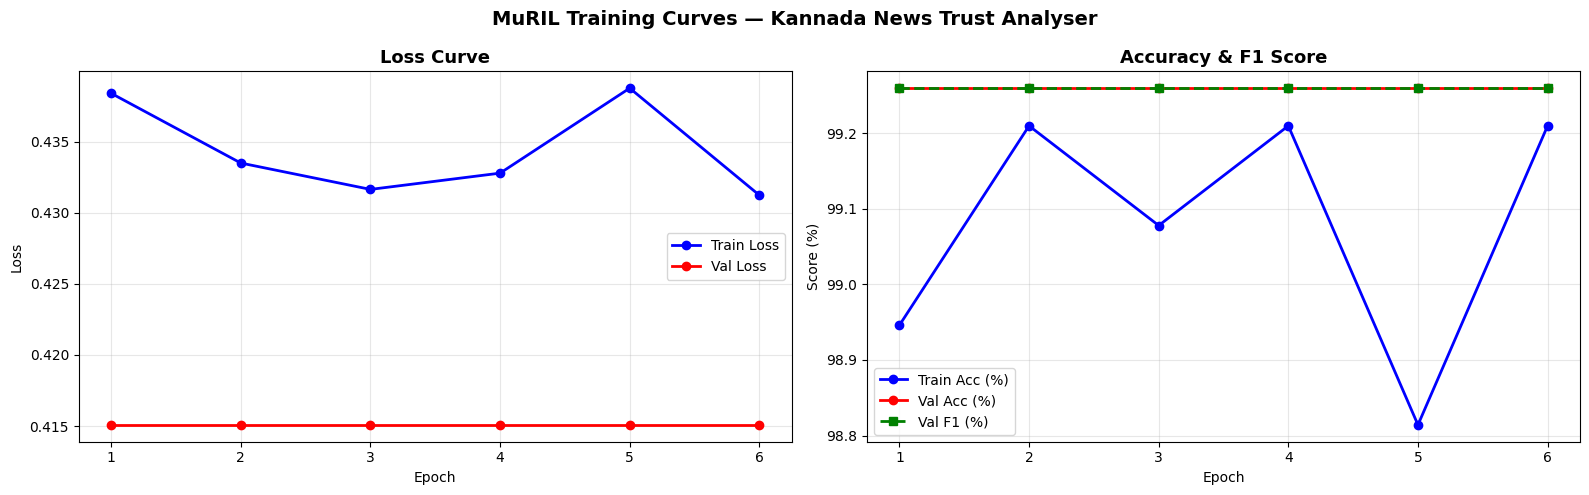

Best Val F1 achieved: 99.26%


In [11]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('MuRIL Training Curves — Kannada News Trust Analyser',
             fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs_ran, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
axes[0].set_title('Loss Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy & F1
axes[1].plot(epochs_ran, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc (%)', linewidth=2)
axes[1].plot(epochs_ran, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc (%)',   linewidth=2)
axes[1].plot(epochs_ran, [f*100 for f in history['val_f1']],    'g-s', label='Val F1 (%)',    linewidth=2, linestyle='--')
axes[1].set_title('Accuracy & F1 Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best Val F1 achieved: {best_val_f1*100:.2f}%')

## ✅ Cell 12 — Final Evaluation on Test Set

In [12]:
# Load the best checkpoint
model.load_state_dict(torch.load(best_model_path, map_location=device))
print('✅ Best model loaded for final evaluation\n')

test_loss, test_acc, test_f1, test_preds, test_labels = eval_epoch(
    model, test_loader, loss_fn, device
)

print('=' * 55)
print('          📊 TEST SET RESULTS (MuRIL)')
print('=' * 55)
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Test F1-Score : {test_f1:.4f}')
print(f'  Test Loss     : {test_loss:.4f}')
print('=' * 55)

✅ Best model loaded for final evaluation

          📊 TEST SET RESULTS (MuRIL)
  Test Accuracy : 94.69%
  Test F1-Score : 0.9468
  Test Loss     : 0.5179


## ✅ Cell 13 — Classification Report

In [13]:
target_names = ['Neutral (0)', 'Offensive (1)', 'Biased (2)']

print('\n📊 Full Classification Report:')
print('=' * 60)
print(classification_report(test_labels, test_preds, target_names=target_names, digits=4))


📊 Full Classification Report:
               precision    recall  f1-score   support

  Neutral (0)     0.9455    0.9811    0.9630        53
Offensive (1)     0.9744    0.9268    0.9500        41
   Biased (2)     0.8947    0.8947    0.8947        19

     accuracy                         0.9469       113
    macro avg     0.9382    0.9342    0.9359       113
 weighted avg     0.9474    0.9469    0.9468       113



## ✅ Cell 14 — Confusion Matrix

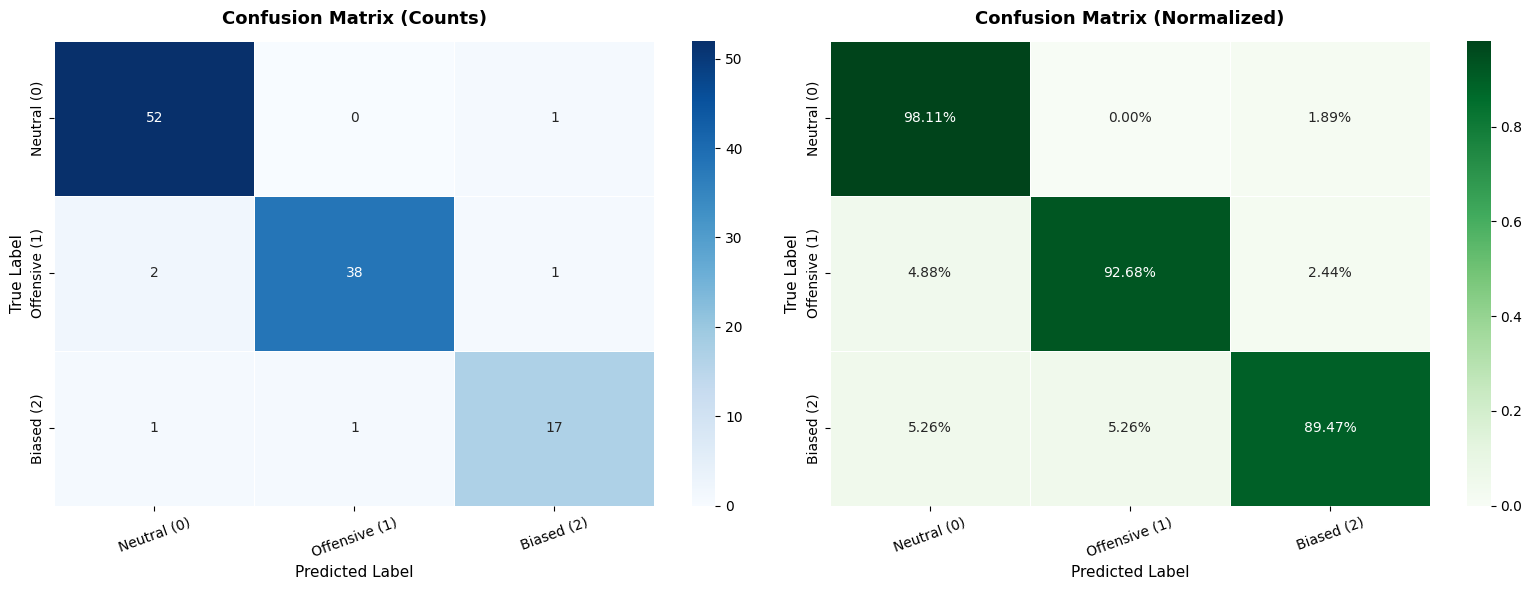


📌 Per-Class Accuracy on Test Set:
  Neutral (0): 98.11%  (52/53 correct)
  Offensive (1): 92.68%  (38/41 correct)
  Biased (2): 89.47%  (17/19 correct)


In [14]:
cm = confusion_matrix(test_labels, test_preds)

# ── Confusion Matrix Heatmap ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names, yticklabels=target_names,
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=20)

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Greens',
    xticklabels=target_names, yticklabels=target_names,
    linewidths=0.5, ax=axes[1]
)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Per-Class Accuracy on Test Set:')
for i, name in enumerate(target_names):
    class_acc = cm[i, i] / cm[i].sum() * 100
    total_cls = cm[i].sum()
    correct   = cm[i, i]
    print(f'  {name}: {class_acc:.2f}%  ({correct}/{total_cls} correct)')

## ✅ Cell 15 — Prediction Function

In [15]:
def predict_headline(text, model, tokenizer, device, max_len=128):
    """
    Predict the label of a Kannada news headline.
    Returns: predicted label (int)
    """
    model.eval()
    label_map  = {0: '✅ Neutral', 1: '🚨 Offensive', 2: '⚠️  Biased'}
    label_desc = {
        0: 'Standard factual news reporting.',
        1: 'Contains offensive/hateful language targeting individuals or groups.',
        2: 'Shows bias towards/against a community, religion, or political group.'
    }

    encoding = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
        pred    = int(probs.argmax())

    print(f'  Headline     : {text}')
    print(f'  Prediction   : {label_map[pred]}')
    print(f'  Description  : {label_desc[pred]}')
    print(f'  Confidence   : {probs[pred]*100:.2f}%')
    print(f'  Probabilities: Neutral={probs[0]*100:.1f}% | Offensive={probs[1]*100:.1f}% | Biased={probs[2]*100:.1f}%')
    print('-' * 70)
    return pred


print('✅ Prediction function ready!')

✅ Prediction function ready!


## ✅ Cell 16 — Sample Predictions on All 3 Classes

In [16]:
sample_headlines = [
    # Neutral examples
    'ಭಾರತ ತಂಡಕ್ಕೆ ಟಿ20 ವಿಶ್ವಕಪ್ ಗೆಲುವು',
    'ರಾಜ್ಯದಲ್ಲಿ ಮಳೆ ಮುನ್ಸೂಚನೆ: ಹವಾಮಾನ ಇಲಾಖೆ ಎಚ್ಚರಿಕೆ',

    # Offensive examples
    'ಪುಂಡರಿಗೆ ಅಂಜಲ್ಲ ಪೊಲೀಸ್ರಂದ್ರೂ ಭಯ ಇಲ್ಲ ಆದ್ರೆ ಹೆಂಡತಿನ ಕಂಡ್ರೆ ಭಯ ಬೀಳ್ತಾನೆ',
    'ಈ ದೇಶದ್ರೋಹಿಗಳನ್ನು ಜೈಲಿಗೆ ಹಾಕಬೇಕು',

    # Biased examples
    'ಸಂತ್ರಸ್ತರ ಸೂರಿಗಾಗಿ ಕೊಟ್ಟ ಜಾಗದಲ್ಲಿ ಮಸೀದಿ ನಿರ್ಮಾಣ ಭುಗಿಲೆದ್ದ ಆಕ್ರೋಶ',
    'ಒಂದು ಸಮಾಜ ದೇಶಕ್ಕೆ ದ್ರೋಹ ಮಾಡುತ್ತಿದೆ'
]

expected = ['Neutral', 'Neutral', 'Offensive', 'Offensive', 'Biased', 'Biased']

print('🔍 Sample Predictions (2 per class):')
print('=' * 70)
for i, h in enumerate(sample_headlines):
    label_group = expected[i]
    print(f'\n[Expected: {label_group}]')
    predict_headline(h, model, tokenizer, device)

🔍 Sample Predictions (2 per class):

[Expected: Neutral]
  Headline     : ಭಾರತ ತಂಡಕ್ಕೆ ಟಿ20 ವಿಶ್ವಕಪ್ ಗೆಲುವು
  Prediction   : ✅ Neutral
  Description  : Standard factual news reporting.
  Confidence   : 48.12%
  Probabilities: Neutral=48.1% | Offensive=20.6% | Biased=31.3%
----------------------------------------------------------------------

[Expected: Neutral]
  Headline     : ರಾಜ್ಯದಲ್ಲಿ ಮಳೆ ಮುನ್ಸೂಚನೆ: ಹವಾಮಾನ ಇಲಾಖೆ ಎಚ್ಚರಿಕೆ
  Prediction   : ✅ Neutral
  Description  : Standard factual news reporting.
  Confidence   : 48.17%
  Probabilities: Neutral=48.2% | Offensive=21.0% | Biased=30.9%
----------------------------------------------------------------------

[Expected: Offensive]
  Headline     : ಪುಂಡರಿಗೆ ಅಂಜಲ್ಲ ಪೊಲೀಸ್ರಂದ್ರೂ ಭಯ ಇಲ್ಲ ಆದ್ರೆ ಹೆಂಡತಿನ ಕಂಡ್ರೆ ಭಯ ಬೀಳ್ತಾನೆ
  Prediction   : ✅ Neutral
  Description  : Standard factual news reporting.
  Confidence   : 47.54%
  Probabilities: Neutral=47.5% | Offensive=21.9% | Biased=30.6%
-----------------------------------------------------------

## ✅ Cell 17 — Interactive Custom Headline Prediction

In [17]:
print('🖊️  Type any Kannada news headline to classify:')
print('   (Type in Kannada script for best results)\n')

user_input = input('Headline: ').strip()
if user_input:
    print()
    predict_headline(user_input, model, tokenizer, device)
else:
    print('⚠️  No headline entered.')

🖊️  Type any Kannada news headline to classify:
   (Type in Kannada script for best results)

Headline: ವಿರೋಧ ಪಕ್ಷ ಯಾವಾಗಲೂ ತಪ್ಪು ಮಾಹಿತಿ ಹರಡುತ್ತದೆ

  Headline     : ವಿರೋಧ ಪಕ್ಷ ಯಾವಾಗಲೂ ತಪ್ಪು ಮಾಹಿತಿ ಹರಡುತ್ತದೆ
  Prediction   : ⚠️  Biased
  Description  : Shows bias towards/against a community, religion, or political group.
  Confidence   : 58.98%
  Probabilities: Neutral=26.0% | Offensive=15.0% | Biased=59.0%
----------------------------------------------------------------------


## ✅ Cell 18 — Save Model Locally & to Google Drive

In [18]:
import os, shutil
from google.colab import drive

SAVE_DIR   = '/content/muril_kannada_news'
DRIVE_PATH = '/content/drive/MyDrive/muril_kannada_news'

os.makedirs(SAVE_DIR, exist_ok=True)

# Save model + tokenizer
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f'✅ Model + Tokenizer saved locally: {SAVE_DIR}')

# Mount drive and save
try:
    drive.mount('/content/drive', force_remount=False)
    shutil.copytree(SAVE_DIR, DRIVE_PATH, dirs_exist_ok=True)
    print(f'✅ Model saved to Google Drive: {DRIVE_PATH}')
except Exception as e:
    print(f'⚠️  Could not save to Drive: {e}')
    print('   Model is saved locally in Colab session.')

print('\n📌 To reload this model later:')
print('   tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)')
print('   model     = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model + Tokenizer saved locally: /content/muril_kannada_news
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved to Google Drive: /content/drive/MyDrive/muril_kannada_news

📌 To reload this model later:
   tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
   model     = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)


## ✅ Cell 19 — Reload & Verify Model

In [19]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print('🔄 Reloading model from saved directory...')
loaded_tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
loaded_model     = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(device)
loaded_model.eval()
print('✅ Model reloaded successfully!\n')

# Sanity check
print('🔍 Sanity Check:')
print('=' * 70)
predict_headline(
    'ಭಾರತ ತಂಡಕ್ಕೆ ಟಿ20 ವಿಶ್ವಕಪ್ ಗೆಲುವು',
    loaded_model, loaded_tokenizer, device
)
predict_headline(
    'ಸಂತ್ರಸ್ತರ ಸೂರಿಗಾಗಿ ಕೊಟ್ಟ ಜಾಗದಲ್ಲಿ ಮಸೀದಿ ನಿರ್ಮಾಣ ಭುಗಿಲೆದ್ದ ಆಕ್ರೋಶ',
    loaded_model, loaded_tokenizer, device
)

🔄 Reloading model from saved directory...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model reloaded successfully!

🔍 Sanity Check:
  Headline     : ಭಾರತ ತಂಡಕ್ಕೆ ಟಿ20 ವಿಶ್ವಕಪ್ ಗೆಲುವು
  Prediction   : ✅ Neutral
  Description  : Standard factual news reporting.
  Confidence   : 48.12%
  Probabilities: Neutral=48.1% | Offensive=20.6% | Biased=31.3%
----------------------------------------------------------------------
  Headline     : ಸಂತ್ರಸ್ತರ ಸೂರಿಗಾಗಿ ಕೊಟ್ಟ ಜಾಗದಲ್ಲಿ ಮಸೀದಿ ನಿರ್ಮಾಣ ಭುಗಿಲೆದ್ದ ಆಕ್ರೋಶ
  Prediction   : 🚨 Offensive
  Description  : Contains offensive/hateful language targeting individuals or groups.
  Confidence   : 41.55%
  Probabilities: Neutral=39.4% | Offensive=41.6% | Biased=19.1%
----------------------------------------------------------------------


1

---
## 🎙️ Cell 21 — Speech Input: Install Whisper + Dependencies

In [20]:
# Install OpenAI Whisper and audio processing libraries
!pip install openai-whisper -q
!pip install librosa soundfile pydub -q
!apt-get install -y ffmpeg -q
print('✅ Whisper + audio libraries installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 51.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
✅ Whisper + audio libraries installed!


## 🎙️ Cell 22 — Load Whisper Model (Kannada ASR)

In [21]:
import whisper
import torch

# ── Load Whisper ───────────────────────────────────────────────────────
# 'medium' gives the best balance of speed vs Kannada accuracy.
# Use 'large-v3' for higher accuracy if GPU memory allows (>10GB VRAM).
# Use 'small' for faster runs on limited resources.
WHISPER_MODEL_SIZE = 'medium'   # Options: tiny | base | small | medium | large-v3

print(f'Loading Whisper {WHISPER_MODEL_SIZE} model...')
whisper_model = whisper.load_model(WHISPER_MODEL_SIZE)
print(f'✅ Whisper {WHISPER_MODEL_SIZE} loaded!')
print(f'   Device: {"GPU" if next(whisper_model.parameters()).is_cuda else "CPU"}')

Loading Whisper medium model...


100%|██████████████████████████████████████| 1.42G/1.42G [00:07<00:00, 207MiB/s]


✅ Whisper medium loaded!
   Device: GPU


## 🎙️ Cell 23 — Transcription Helper Function

In [22]:
def transcribe_kannada_audio(audio_path, whisper_model):
    """
    Transcribe a Kannada audio file using Whisper.

    Args:
        audio_path   : Path to audio file (.wav / .mp3 / .ogg / .m4a / .flac)
        whisper_model: Loaded Whisper model

    Returns:
        transcript (str) — Kannada text extracted from audio
    """
    print(f'🎧 Transcribing: {audio_path}')

    # Force Whisper to treat input as Kannada (language code: 'kn')
    # This avoids Whisper auto-detecting the wrong language.
    result = whisper_model.transcribe(
    audio_path,
    language='kn',
    task='transcribe',
    fp16=torch.cuda.is_available(),
    temperature=0.0,                   # ADD THIS
    condition_on_previous_text=False,  # ADD THIS
    verbose=False
)

    transcript = result['text'].strip()
    print(f'✅ Transcription complete!')
    print(f'📝 Detected language : {result.get("language", "kn")}')
    print(f'📝 Transcript        : {transcript}')
    return transcript

print('✅ transcribe_kannada_audio() function ready!')

✅ transcribe_kannada_audio() function ready!


## 🎙️ Cell 24 — Upload Audio File & Transcribe

In [23]:
from google.colab import files

print('🎤 Upload your Kannada audio file (.wav / .mp3 / .ogg / .m4a / .flac):')
uploaded_audio = files.upload()

# Get uploaded audio path
audio_path = list(uploaded_audio.keys())[0]
print(f'\n📂 Uploaded: {audio_path}')

# Transcribe using Whisper
kannada_transcript = transcribe_kannada_audio(audio_path, whisper_model)

print()
print('─' * 60)
print('📝 Final Transcript:')
print(kannada_transcript)
print('─' * 60)

🎤 Upload your Kannada audio file (.wav / .mp3 / .ogg / .m4a / .flac):


Saving speech.mp3 to speech.mp3

📂 Uploaded: speech.mp3
🎧 Transcribing: speech.mp3


100%|██████████| 472/472 [00:03<00:00, 132.23frames/s]

✅ Transcription complete!
📝 Detected language : kn
📝 Transcript        : ವಿರೂದಪಕ್ಷಯ ಯಾವಕಲು ತಪ್ಪ್ಪ್ಪ್ತಿಹರಿದಿದೇ.

────────────────────────────────────────────────────────────
📝 Final Transcript:
ವಿರೂದಪಕ್ಷಯ ಯಾವಕಲು ತಪ್ಪ್ಪ್ಪ್ತಿಹರಿದಿದೇ.
────────────────────────────────────────────────────────────


## 🎙️ Cell 25 — Classify Transcribed Text with MuRIL

In [24]:
# ── Classify the transcript using your already-trained MuRIL model ─────
# This reuses predict_headline() defined in Cell 15 of this notebook.

if kannada_transcript and kannada_transcript.strip():

    print('🔍 Running MuRIL classifier on transcribed text...')
    print(f'   Input text : {kannada_transcript}')
    print()

    predicted_label = predict_headline(
        text      = kannada_transcript,
        model     = model,   # Your fine-tuned MuRIL from Cell 19
        tokenizer = tokenizer,
        device    = device
    )

    label_map  = {0: 'Neutral', 1: 'Offensive', 2: 'Biased'}
    emoji_map  = {0: '✅', 1: '🚨', 2: '⚠️'}
    label_name = label_map[predicted_label]
    emoji      = emoji_map[predicted_label]

    print('=' * 60)
    print('  🎙️  SPEECH → TEXT → CLASSIFICATION RESULT')
    print('=' * 60)
    print(f'  Audio File  : {audio_path}')
    print(f'  Transcript  : {kannada_transcript}')
    print(f'  Prediction  : {emoji} {label_name} (Label {predicted_label})')
    print('=' * 60)

else:
    print('⚠️  Whisper returned an empty transcript.')
    print('   Possible reasons:')
    print('   1. Audio is too noisy or too short (< 1 second)')
    print('   2. Audio contains no speech')
    print('   3. Try re-recording with a clearer microphone')
    print('   Tip: use medium or large-v3 model for better accuracy')

🔍 Running MuRIL classifier on transcribed text...
   Input text : ವಿರೂದಪಕ್ಷಯ ಯಾವಕಲು ತಪ್ಪ್ಪ್ಪ್ತಿಹರಿದಿದೇ.

  Headline     : ವಿರೂದಪಕ್ಷಯ ಯಾವಕಲು ತಪ್ಪ್ಪ್ಪ್ತಿಹರಿದಿದೇ.
  Prediction   : ⚠️  Biased
  Description  : Shows bias towards/against a community, religion, or political group.
  Confidence   : 57.75%
  Probabilities: Neutral=28.6% | Offensive=13.7% | Biased=57.8%
----------------------------------------------------------------------
  🎙️  SPEECH → TEXT → CLASSIFICATION RESULT
  Audio File  : speech.mp3
  Transcript  : ವಿರೂದಪಕ್ಷಯ ಯಾವಕಲು ತಪ್ಪ್ಪ್ಪ್ತಿಹರಿದಿದೇ.
  Prediction  : ⚠️ Biased (Label 2)


In [25]:
!pip install gradio -q
print('✅ Gradio installed!')

✅ Gradio installed!


In [26]:
!pip install gradio easyocr -q
print('✅ Done!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 14.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-learn 1.3.2 requires numpy<2.0,>=1.17.3, but you have numpy 2.4.4 which is incompatible.
spopt 0.7.0 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.

In [27]:
!pip install openai-whisper -q
!apt-get install -y ffmpeg -q
print('✅ Done!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 46.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-learn 1.3.2 requires numpy<2.0,>=1.17.3, but you have numpy 2.0.2 which is incompatible.
spopt 0.7.0 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.
cuml-cu12 26.2.0 requires scikit-learn>=1.5, but you have scikit-learn 1.3.2 which is incompatible.
mapclassify 2.10.0 requires scikit-learn>=1.4, but you have scikit-learn 1.3.2 which is incompatible.
esda 2.9.0 requires scikit-learn>=1.4, but you have scikit-learn 1.3.2 which is incompatible.
libpysal 4.14.1 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.

In [28]:
import gradio as gr
import torch
import numpy as np
import easyocr
import whisper

print('Loading EasyOCR for Kannada...')
reader = easyocr.Reader(['kn', 'en'], gpu=torch.cuda.is_available())
print('✅ EasyOCR ready!')

print('Loading Whisper medium model...')
whisper_model = whisper.load_model('medium')
print('✅ Whisper ready!')

# ── Core Classifier ────────────────────────────────────────────────────
def run_classifier(text):
    if not text or not text.strip():
        return ('', 0, 0, 0)
    model.eval()
    encoding = tokenizer(
        text.strip(),
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
        pred    = int(probs.argmax())
    label_info = {
        0: ('NEUTRAL',   '#22c55e', 'This headline is factual and unbiased. It reports news without targeting any group.'),
        1: ('OFFENSIVE', '#ef4444', 'This headline contains offensive, hateful, or derogatory language targeting individuals or groups.'),
        2: ('BIASED',    '#f59e0b', 'This headline shows bias favouring or targeting a community, religion, or political group unfairly.')
    }
    label_text, color, description = label_info[pred]
    confidence = float(probs[pred]) * 100
    conf_str   = '{:.1f}'.format(confidence) + '%'
    neutral_p  = round(float(probs[0]) * 100, 1)
    offens_p   = round(float(probs[1]) * 100, 1)
    biased_p   = round(float(probs[2]) * 100, 1)
    verdict = (
        '<div style="background:linear-gradient(135deg,'
        + color + '18,' + color + '08);'
        + 'border:2px solid ' + color + ';'
        + 'border-radius:16px;padding:28px;'
        + 'font-family:Georgia,serif;text-align:center;">'
        + '<div style="font-size:2.4rem;font-weight:900;color:' + color
        + ';letter-spacing:3px;margin-bottom:8px;">' + label_text + '</div>'
        + '<div style="font-size:1.4rem;color:' + color
        + ';font-weight:700;margin-bottom:14px;">Confidence: ' + conf_str + '</div>'
        + '<div style="font-size:0.9rem;color:#9ca3af;line-height:1.7;'
        + 'max-width:400px;margin:0 auto;">' + description + '</div>'
        + '</div>'
    )
    return (verdict, neutral_p, offens_p, biased_p)

# ── Text Pipeline ──────────────────────────────────────────────────────
def classify_from_text(headline):
    return run_classifier(headline)

# ── Image Pipeline ─────────────────────────────────────────────────────
def classify_from_image(image):
    if image is None:
        empty = (
            '<div style="border:2px dashed #374151;border-radius:16px;'
            + 'padding:28px;text-align:center;color:#6b7280;">'
            + 'Please upload an image to analyse.</div>'
        )
        return (empty, '', 0, 0, 0)
    try:
        results   = reader.readtext(image, detail=0, paragraph=True)
        extracted = ' '.join(results).strip()
    except Exception as e:
        err = (
            '<div style="border:2px solid #ef4444;border-radius:16px;'
            + 'padding:20px;text-align:center;color:#ef4444;">'
            + 'OCR failed: ' + str(e) + '</div>'
        )
        return (err, '', 0, 0, 0)
    if not extracted:
        no_text = (
            '<div style="border:2px dashed #f59e0b;border-radius:16px;'
            + 'padding:28px;text-align:center;color:#f59e0b;">'
            + 'No Kannada text found. Try a clearer image.</div>'
        )
        return (no_text, '', 0, 0, 0)
    verdict, n, o, b = run_classifier(extracted)
    return (verdict, extracted, n, o, b)

def image_pipeline(image):
    verdict, extracted, n, o, b = classify_from_image(image)
    if extracted:
        ocr_html = (
            '<div style="background:#0f172a;border:1px solid #06b6d430;'
            + 'border-radius:12px;padding:14px 16px;margin-top:10px;">'
            + '<p style="color:#06b6d4;font-size:0.7rem;letter-spacing:2px;'
            + 'text-transform:uppercase;font-weight:700;margin:0 0 6px;">OCR Extracted Text</p>'
            + '<p style="color:#e2e8f0;font-size:0.95rem;line-height:1.7;margin:0;">'
            + extracted + '</p></div>'
        )
    else:
        ocr_html = ''
    return (verdict, ocr_html, n, o, b)

# ── Audio Pipeline (NEW) ───────────────────────────────────────────────
def audio_pipeline(audio_path):
    """
    Takes an audio file path from Gradio's Audio component,
    transcribes it using Whisper (forced Kannada),
    then classifies via MuRIL.
    Returns: verdict_html, transcript_html, neutral%, offensive%, biased%
    """
    # Empty state HTML
    def make_transcript_html(text, color='#a78bfa', label='Whisper Transcript'):
        return (
            '<div style="background:#0f172a;border:1px solid ' + color + '30;'
            + 'border-radius:12px;padding:14px 16px;margin-top:10px;">'
            + '<p style="color:' + color + ';font-size:0.7rem;letter-spacing:2px;'
            + 'text-transform:uppercase;font-weight:700;margin:0 0 6px;">' + label + '</p>'
            + '<p style="color:#e2e8f0;font-size:0.95rem;line-height:1.7;margin:0;">'
            + text + '</p></div>'
        )

    if audio_path is None:
        empty = (
            '<div style="border:2px dashed #374151;border-radius:16px;'
            + 'padding:28px;text-align:center;color:#6b7280;">'
            + 'Please upload or record audio to analyse.</div>'
        )
        return (empty, '', 0, 0, 0)

    # ── Transcribe with Whisper ────────────────────────────────────────
    try:
        result     = whisper_model.transcribe(
            audio_path,
            language='kn',                       # Force Kannada — critical
            task='transcribe',
            fp16=torch.cuda.is_available(),
            verbose=False
        )
        transcript = result['text'].strip()
    except Exception as e:
        err = (
            '<div style="border:2px solid #ef4444;border-radius:16px;'
            + 'padding:20px;text-align:center;color:#ef4444;">'
            + 'Whisper transcription failed: ' + str(e) + '</div>'
        )
        return (err, '', 0, 0, 0)

    if not transcript:
        no_speech = (
            '<div style="border:2px dashed #f59e0b;border-radius:16px;'
            + 'padding:28px;text-align:center;color:#f59e0b;">'
            + '⚠️ No speech detected. Try clearer audio or re-record.</div>'
        )
        return (no_speech, make_transcript_html('(empty)', '#f59e0b'), 0, 0, 0)

    # ── Classify transcript with MuRIL ────────────────────────────────
    verdict, n, o, b = run_classifier(transcript)
    transcript_html  = make_transcript_html(transcript)
    return (verdict, transcript_html, n, o, b)


# ── Samples & CSS (unchanged from your original) ──────────────────────
SAMPLES = [
    ['ಭಾರತ ತಂಡಕ್ಕೆ ಟಿ20 ವಿಶ್ವಕಪ್ ಗೆಲುವು'],
    ['ರಾಜ್ಯ ಬಜೆಟ್ ಅಧಿವೇಶನ ಫೆಬ್ರವರಿಯಲ್ಲಿ ಆರಂಭ'],
    ['ಬೆಂಗಳೂರಿನಲ್ಲಿ ಮೆಟ್ರೋ ಸೇವೆ ವಿಸ್ತರಣೆ'],
    ['ಈ ದೇಶದ್ರೋಹಿಗಳನ್ನು ಜೈಲಿಗೆ ಹಾಕಬೇಕು'],
    ['ಮಹಿಳೆಯರು ಮನೆಯಲ್ಲಿ ಇರಬೇಕು ರಾಜಕೀಯದಲ್ಲಿ ಏನು ಕೆಲಸ'],
    ['ಆ ನಾಯಿಗಳಿಗೆ ಇನ್ನು ಈ ದೇಶದಲ್ಲಿ ಜಾಗವಿಲ್ಲ'],
    ['ಸಂತ್ರಸ್ತರ ಸೂರಿಗಾಗಿ ಕೊಟ್ಟ ಜಾಗದಲ್ಲಿ ಮಸೀದಿ ನಿರ್ಮಾಣ ಭುಗಿಲೆದ್ದ ಆಕ್ರೋಶ'],
    ['ವಲಸಿಗರಿಂದ ಕನ್ನಡಿಗರ ಉದ್ಯೋಗ ಕಸಿದುಕೊಳ್ಳಲಾಗುತ್ತಿದೆ'],
    ['ಕಾಂಗ್ರೆಸ್ ಸರ್ಕಾರ ಯಾವಾಗಲೂ ಅಲ್ಪಸಂಖ್ಯಾತರ ಪರ ಮಾತ್ರ ಕೆಲಸ ಮಾಡುತ್ತದೆ'],
]

CSS = """
@import url('https://fonts.googleapis.com/css2?family=Playfair+Display:wght@700;900&family=DM+Sans:wght@300;400;500;600&display=swap');
body, .gradio-container { background:#0d0d0d !important; font-family:'DM Sans',sans-serif !important; }
.header-wrap { background:linear-gradient(135deg,#0d0d0d,#1a1a2e,#0d0d0d); border-bottom:1px solid #2a2a3e; padding:36px 20px 28px; text-align:center; }
.title-main { font-family:'Playfair Display',serif !important; font-size:2.6rem !important; font-weight:900 !important; color:#f8f8f8 !important; letter-spacing:-1px; margin:0 0 6px 0 !important; }
.title-accent { color:#818cf8 !important; }
.subtitle { color:#6b7280 !important; font-size:0.88rem !important; letter-spacing:3px; text-transform:uppercase; font-weight:500; margin:0 !important; }
.badge-row { display:flex; gap:8px; justify-content:center; flex-wrap:wrap; margin-top:16px; }
.badge { background:#1f2937; border:1px solid #374151; border-radius:999px; padding:3px 12px; font-size:0.72rem; color:#9ca3af; letter-spacing:1px; text-transform:uppercase; font-weight:600; }
.badge.muril { border-color:#818cf8; color:#818cf8; background:#818cf810; }
.badge.neutral { border-color:#22c55e; color:#22c55e; background:#22c55e10; }
.badge.offensive { border-color:#ef4444; color:#ef4444; background:#ef444410; }
.badge.biased { border-color:#f59e0b; color:#f59e0b; background:#f59e0b10; }
.badge.ocr { border-color:#06b6d4; color:#06b6d4; background:#06b6d410; }
.badge.whisper { border-color:#a78bfa; color:#a78bfa; background:#a78bfa10; }
.gr-textbox textarea { background:#111827 !important; border:1.5px solid #1f2937 !important; border-radius:12px !important; color:#f3f4f6 !important; font-size:1rem !important; padding:14px !important; }
.gr-textbox textarea:focus { border-color:#818cf8 !important; box-shadow:0 0 0 3px #818cf820 !important; }
.gr-button { font-weight:600 !important; border-radius:10px !important; transition:all 0.2s ease !important; }
.gr-button.primary { background:linear-gradient(135deg,#6366f1,#818cf8) !important; border:none !important; color:white !important; }
.gr-button.primary:hover { transform:translateY(-2px) !important; box-shadow:0 8px 25px #6366f140 !important; }
.gr-button.secondary { background:#1f2937 !important; border:1px solid #374151 !important; color:#9ca3af !important; }
.gr-group, .gr-form { background:#111827 !important; border:1px solid #1f2937 !important; border-radius:16px !important; }
label, .gr-label { color:#6b7280 !important; font-size:0.75rem !important; letter-spacing:1.5px !important; text-transform:uppercase !important; font-weight:600 !important; }
.tab-nav button { font-family:'DM Sans',sans-serif !important; font-weight:600 !important; color:#6b7280 !important; }
.tab-nav button.selected { color:#818cf8 !important; border-bottom:2px solid #818cf8 !important; }
.footer-note { text-align:center; color:#374151; font-size:0.76rem; margin-top:10px; letter-spacing:1px; }
"""

# ── Gradio UI ──────────────────────────────────────────────────────────
with gr.Blocks(css=CSS, title='Kannada News Trust Analyser') as demo:

    gr.HTML("""
    <div class="header-wrap">
        <p class="subtitle">ಕನ್ನಡ ಸುದ್ದಿ ವಿಶ್ವಾಸಾರ್ಹತೆ ವಿಶ್ಲೇಷಕ</p>
        <h1 class="title-main">Kannada News <span class="title-accent">Trust Analyser</span></h1>
        <div class="badge-row">
            <span class="badge muril">MuRIL Model</span>
            <span class="badge neutral">Neutral</span>
            <span class="badge offensive">Offensive</span>
            <span class="badge biased">Biased</span>
            <span class="badge ocr">EasyOCR</span>
            <span class="badge whisper">Whisper ASR</span>
            <span class="badge">20 Epochs</span>
        </div>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=5):
            gr.HTML('<div style="height:14px"></div>')
            with gr.Tabs():

                # ── Tab 1: Text ────────────────────────────────────────
                with gr.Tab('📝  Text Input'):
                    headline_input = gr.Textbox(
                        label='Enter Kannada Headline',
                        placeholder='ಇಲ್ಲಿ ಕನ್ನಡ ಸುದ್ದಿ ಶೀರ್ಷಿಕೆ ಟೈಪ್ ಮಾಡಿ...',
                        lines=3, max_lines=5
                    )
                    with gr.Row():
                        text_submit = gr.Button('Analyse Headline', variant='primary', scale=3)
                        text_clear  = gr.Button('Clear',            variant='secondary', scale=1)

                # ── Tab 2: Image ───────────────────────────────────────
                with gr.Tab('🖼️  Image / Photo'):
                    image_input = gr.Image(
                        label='Upload Newspaper or Screenshot',
                        type='numpy',
                        height=220
                    )
                    with gr.Row():
                        img_submit = gr.Button('Extract & Analyse', variant='primary', scale=3)
                        img_clear  = gr.Button('Clear',             variant='secondary', scale=1)
                    ocr_display = gr.HTML()

                # ── Tab 3: Audio (NEW) ─────────────────────────────────
                with gr.Tab('🎙️  Audio / Speech'):
                    gr.HTML("""
                    <div style="background:#0f172a;border:1px solid #a78bfa30;
                    border-radius:12px;padding:12px 16px;margin-bottom:12px;">
                        <p style="color:#a78bfa;font-size:0.7rem;letter-spacing:2px;
                        text-transform:uppercase;font-weight:700;margin:0 0 4px;">How it works</p>
                        <p style="color:#6b7280;font-size:0.8rem;line-height:1.7;margin:0;">
                        Upload or record a Kannada audio clip → Whisper transcribes it →
                        MuRIL classifies the transcript as Neutral / Offensive / Biased.
                        </p>
                    </div>
                    """)
                    audio_input = gr.Audio(
                        label='Upload or Record Kannada Audio',
                        type='filepath',        # Whisper needs a file path
                        sources=['upload'],
                    )
                    with gr.Row():
                        audio_submit = gr.Button('Transcribe & Analyse', variant='primary', scale=3)
                        audio_clear  = gr.Button('Clear',                variant='secondary', scale=1)
                    audio_transcript_display = gr.HTML()   # Shows Whisper transcript

            gr.HTML('<div style="height:10px"></div>')
            verdict_html = gr.HTML()
            gr.HTML('<p style="color:#4b5563;font-size:0.72rem;letter-spacing:2px;text-transform:uppercase;font-weight:600;margin:18px 0 8px;">Class Probabilities</p>')
            with gr.Group():
                neutral_bar   = gr.Slider(0, 100, value=0, label='Neutral (%)',   interactive=False)
                offensive_bar = gr.Slider(0, 100, value=0, label='Offensive (%)', interactive=False)
                biased_bar    = gr.Slider(0, 100, value=0, label='Biased (%)',    interactive=False)

        # ── Right Column ───────────────────────────────────────────────
        with gr.Column(scale=3):
            gr.HTML('<div style="height:14px"></div>')
            gr.HTML('<p style="color:#4b5563;font-size:0.72rem;letter-spacing:2px;text-transform:uppercase;font-weight:600;margin:0 0 8px;">Sample Headlines</p>')
            gr.HTML('<p style="color:#22c55e;font-size:0.68rem;letter-spacing:2px;margin:10px 0 4px;text-transform:uppercase;">Neutral</p>')
            gr.Examples(examples=SAMPLES[:3], inputs=headline_input, label='')
            gr.HTML('<p style="color:#ef4444;font-size:0.68rem;letter-spacing:2px;margin:14px 0 4px;text-transform:uppercase;">Offensive</p>')
            gr.Examples(examples=SAMPLES[3:6], inputs=headline_input, label='')
            gr.HTML('<p style="color:#f59e0b;font-size:0.68rem;letter-spacing:2px;margin:14px 0 4px;text-transform:uppercase;">Biased</p>')
            gr.Examples(examples=SAMPLES[6:], inputs=headline_input, label='')
            gr.HTML("""
            <div style="background:#0f172a;border:1px solid #1e293b;border-radius:12px;padding:16px 18px;margin-top:18px;">
                <p style="color:#6366f1;font-size:0.7rem;letter-spacing:2px;text-transform:uppercase;font-weight:700;margin:0 0 10px;">Model Info</p>
                <div style="color:#6b7280;font-size:0.8rem;line-height:1.9;">
                    <div>Model &mdash; google/muril-base-cased</div>
                    <div>Languages &mdash; 17 Indian + English</div>
                    <div>OCR &mdash; EasyOCR (Kannada + English)</div>
                    <div>ASR &mdash; Whisper medium (Kannada)</div>
                    <div>Classes &mdash; Neutral / Offensive / Biased</div>
                    <div>Epochs &mdash; 20 (early stopping)</div>
                </div>
            </div>
            """)
            gr.HTML("""
            <div style="background:#0f172a;border:1px solid #06b6d430;border-radius:12px;padding:16px 18px;margin-top:12px;">
                <p style="color:#06b6d4;font-size:0.7rem;letter-spacing:2px;text-transform:uppercase;font-weight:700;margin:0 0 10px;">Image Tips</p>
                <div style="color:#6b7280;font-size:0.78rem;line-height:1.9;">
                    <div>📸 Clear, well-lit photos work best</div>
                    <div>🗞️ Newspaper or website screenshots</div>
                    <div>🔍 Headline should be large and clear</div>
                    <div>📱 Mobile screenshots work great</div>
                    <div>🚫 Avoid blurry or rotated images</div>
                </div>
            </div>
            """)
            gr.HTML("""
            <div style="background:#0f172a;border:1px solid #a78bfa30;border-radius:12px;padding:16px 18px;margin-top:12px;">
                <p style="color:#a78bfa;font-size:0.7rem;letter-spacing:2px;text-transform:uppercase;font-weight:700;margin:0 0 10px;">Audio Tips</p>
                <div style="color:#6b7280;font-size:0.78rem;line-height:1.9;">
                    <div>🎙️ Speak clearly in Kannada</div>
                    <div>🔇 Avoid background noise</div>
                    <div>⏱️ 3–10 seconds is ideal length</div>
                    <div>📁 Supports .wav .mp3 .ogg .m4a</div>
                    <div>🖥️ Or use mic to record live</div>
                </div>
            </div>
            """)

    gr.HTML('<p class="footer-note">KANNADA NEWS TRUST ANALYSER &nbsp;&middot;&nbsp; MuRIL + EasyOCR + Whisper &nbsp;&middot;&nbsp; GOOGLE COLAB</p>')

    # ── Event Bindings ─────────────────────────────────────────────────

    # Text tab
    text_submit.click(
        fn=classify_from_text,
        inputs=[headline_input],
        outputs=[verdict_html, neutral_bar, offensive_bar, biased_bar]
    )
    headline_input.submit(
        fn=classify_from_text,
        inputs=[headline_input],
        outputs=[verdict_html, neutral_bar, offensive_bar, biased_bar]
    )
    text_clear.click(
        fn=lambda: ('', 0, 0, 0, ''),
        inputs=[],
        outputs=[headline_input, neutral_bar, offensive_bar, biased_bar, verdict_html]
    )

    # Image tab
    img_submit.click(
        fn=image_pipeline,
        inputs=[image_input],
        outputs=[verdict_html, ocr_display, neutral_bar, offensive_bar, biased_bar]
    )
    img_clear.click(
        fn=lambda: (None, '', 0, 0, 0, ''),
        inputs=[],
        outputs=[image_input, ocr_display, neutral_bar, offensive_bar, biased_bar, verdict_html]
    )

    # Audio tab (NEW)
    audio_submit.click(
        fn=audio_pipeline,
        inputs=[audio_input],
        outputs=[verdict_html, audio_transcript_display, neutral_bar, offensive_bar, biased_bar]
    )
    audio_clear.click(
        fn=lambda: (None, '', 0, 0, 0, ''),
        inputs=[],
        outputs=[audio_input, audio_transcript_display, neutral_bar, offensive_bar, biased_bar, verdict_html]
    )

demo.launch(share=True, debug=False, show_error=True, quiet=True)


Loading EasyOCR for Kannada...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete✅ EasyOCR ready!
Loading Whisper medium model...
✅ Whisper ready!
* Running on public URL: https://10b1fbd468577ce839.gradio.live


In [29]:
import gradio as gr
import torch
import numpy as np
import easyocr

print('Loading EasyOCR for Kannada...')
reader = easyocr.Reader(['kn', 'en'], gpu=torch.cuda.is_available())
print('✅ EasyOCR ready!')

# ── MODIFIED: added is_image parameter ────────────────────────────────
def run_classifier(text, is_image=False):
    if not text or not text.strip():
        return ('', 0, 0, 0)
    model.eval()
    encoding = tokenizer(
        text.strip(),
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
        pred    = int(probs.argmax())

    # ── Image mode: stricter threshold ─────────────────────────────────
    if is_image:
        neutral_prob   = float(probs[0])
        offensive_prob = float(probs[1])
        biased_prob    = float(probs[2])

        # If Neutral but not confident → pick next highest
        if pred == 0 and neutral_prob < 0.60:
            if offensive_prob >= biased_prob:
                pred = 1
            else:
                pred = 2

        # If Offensive or Biased > 25% → don't say Neutral
        if pred == 0 and (offensive_prob > 0.25 or biased_prob > 0.25):
            if offensive_prob >= biased_prob:
                pred = 1
            else:
                pred = 2

    label_info = {
        0: ('NEUTRAL',   '#22c55e', 'This headline is factual and unbiased. It reports news without targeting any group.'),
        1: ('OFFENSIVE', '#ef4444', 'This headline contains offensive, hateful, or derogatory language targeting individuals or groups.'),
        2: ('BIASED',    '#f59e0b', 'This headline shows bias favouring or targeting a community, religion, or political group unfairly.')
    }
    label_text, color, description = label_info[pred]
    confidence = float(probs[pred]) * 100
    conf_str   = '{:.1f}'.format(confidence) + '%'
    neutral_p  = round(float(probs[0]) * 100, 1)
    offens_p   = round(float(probs[1]) * 100, 1)
    biased_p   = round(float(probs[2]) * 100, 1)
    verdict = (
        '<div style="background:linear-gradient(135deg,'
        + color + '18,' + color + '08);'
        + 'border:2px solid ' + color + ';'
        + 'border-radius:16px;padding:28px;'
        + 'font-family:Georgia,serif;text-align:center;">'
        + '<div style="font-size:2.4rem;font-weight:900;color:' + color
        + ';letter-spacing:3px;margin-bottom:8px;">' + label_text + '</div>'
        + '<div style="font-size:1.4rem;color:' + color
        + ';font-weight:700;margin-bottom:14px;">Confidence: ' + conf_str + '</div>'
        + '<div style="font-size:0.9rem;color:#9ca3af;line-height:1.7;'
        + 'max-width:400px;margin:0 auto;">' + description + '</div>'
        + '</div>'
    )
    return (verdict, neutral_p, offens_p, biased_p)

# ── MODIFIED: is_image=False ───────────────────────────────────────────
def classify_from_text(headline):
    return run_classifier(headline, is_image=False)

def classify_from_image(image):
    if image is None:
        empty = (
            '<div style="border:2px dashed #374151;border-radius:16px;'
            + 'padding:28px;text-align:center;color:#6b7280;">'
            + 'Please upload an image to analyse.</div>'
        )
        return (empty, '', 0, 0, 0)
    try:
        results   = reader.readtext(image, detail=0, paragraph=True)
        extracted = ' '.join(results).strip()
    except Exception as e:
        err = (
            '<div style="border:2px solid #ef4444;border-radius:16px;'
            + 'padding:20px;text-align:center;color:#ef4444;">'
            + 'OCR failed: ' + str(e) + '</div>'
        )
        return (err, '', 0, 0, 0)
    if not extracted:
        no_text = (
            '<div style="border:2px dashed #f59e0b;border-radius:16px;'
            + 'padding:28px;text-align:center;color:#f59e0b;">'
            + 'No Kannada text found. Try a clearer image.</div>'
        )
        return (no_text, '', 0, 0, 0)

    # ── MODIFIED: is_image=True ────────────────────────────────────────
    verdict, n, o, b = run_classifier(extracted, is_image=True)
    return (verdict, extracted, n, o, b)

def image_pipeline(image):
    verdict, extracted, n, o, b = classify_from_image(image)
    if extracted:
        ocr_html = (
            '<div style="background:#0f172a;border:1px solid #06b6d430;'
            + 'border-radius:12px;padding:14px 16px;margin-top:10px;">'
            + '<p style="color:#06b6d4;font-size:0.7rem;letter-spacing:2px;'
            + 'text-transform:uppercase;font-weight:700;margin:0 0 6px;">OCR Extracted Text</p>'
            + '<p style="color:#e2e8f0;font-size:0.95rem;line-height:1.7;margin:0;">'
            + extracted + '</p></div>'
        )
    else:
        ocr_html = ''
    return (verdict, ocr_html, n, o, b)


SAMPLES = [
    ['ಭಾರತ ತಂಡಕ್ಕೆ ಟಿ20 ವಿಶ್ವಕಪ್ ಗೆಲುವು'],
    ['ರಾಜ್ಯ ಬಜೆಟ್ ಅಧಿವೇಶನ ಫೆಬ್ರವರಿಯಲ್ಲಿ ಆರಂಭ'],
    ['ಬೆಂಗಳೂರಿನಲ್ಲಿ ಮೆಟ್ರೋ ಸೇವೆ ವಿಸ್ತರಣೆ'],
    ['ಈ ದೇಶದ್ರೋಹಿಗಳನ್ನು ಜೈಲಿಗೆ ಹಾಕಬೇಕು'],
    ['ಮಹಿಳೆಯರು ಮನೆಯಲ್ಲಿ ಇರಬೇಕು ರಾಜಕೀಯದಲ್ಲಿ ಏನು ಕೆಲಸ'],
    ['ಆ ನಾಯಿಗಳಿಗೆ ಇನ್ನು ಈ ದೇಶದಲ್ಲಿ ಜಾಗವಿಲ್ಲ'],
    ['ಸಂತ್ರಸ್ತರ ಸೂರಿಗಾಗಿ ಕೊಟ್ಟ ಜಾಗದಲ್ಲಿ ಮಸೀದಿ ನಿರ್ಮಾಣ ಭುಗಿಲೆದ್ದ ಆಕ್ರೋಶ'],
    ['ವಲಸಿಗರಿಂದ ಕನ್ನಡಿಗರ ಉದ್ಯೋಗ ಕಸಿದುಕೊಳ್ಳಲಾಗುತ್ತಿದೆ'],
    ['ಕಾಂಗ್ರೆಸ್ ಸರ್ಕಾರ ಯಾವಾಗಲೂ ಅಲ್ಪಸಂಖ್ಯಾತರ ಪರ ಮಾತ್ರ ಕೆಲಸ ಮಾಡುತ್ತದೆ'],
]

CSS = """
@import url('https://fonts.googleapis.com/css2?family=Playfair+Display:wght@700;900&family=DM+Sans:wght@300;400;500;600&display=swap');
body, .gradio-container { background:#0d0d0d !important; font-family:'DM Sans',sans-serif !important; }
.header-wrap { background:linear-gradient(135deg,#0d0d0d,#1a1a2e,#0d0d0d); border-bottom:1px solid #2a2a3e; padding:36px 20px 28px; text-align:center; }
.title-main { font-family:'Playfair Display',serif !important; font-size:2.6rem !important; font-weight:900 !important; color:#f8f8f8 !important; letter-spacing:-1px; margin:0 0 6px 0 !important; }
.title-accent { color:#818cf8 !important; }
.subtitle { color:#6b7280 !important; font-size:0.88rem !important; letter-spacing:3px; text-transform:uppercase; font-weight:500; margin:0 !important; }
.badge-row { display:flex; gap:8px; justify-content:center; flex-wrap:wrap; margin-top:16px; }
.badge { background:#1f2937; border:1px solid #374151; border-radius:999px; padding:3px 12px; font-size:0.72rem; color:#9ca3af; letter-spacing:1px; text-transform:uppercase; font-weight:600; }
.badge.muril { border-color:#818cf8; color:#818cf8; background:#818cf810; }
.badge.neutral { border-color:#22c55e; color:#22c55e; background:#22c55e10; }
.badge.offensive { border-color:#ef4444; color:#ef4444; background:#ef444410; }
.badge.biased { border-color:#f59e0b; color:#f59e0b; background:#f59e0b10; }
.badge.ocr { border-color:#06b6d4; color:#06b6d4; background:#06b6d410; }
.gr-textbox textarea { background:#111827 !important; border:1.5px solid #1f2937 !important; border-radius:12px !important; color:#f3f4f6 !important; font-size:1rem !important; padding:14px !important; }
.gr-textbox textarea:focus { border-color:#818cf8 !important; box-shadow:0 0 0 3px #818cf820 !important; }
.gr-button { font-weight:600 !important; border-radius:10px !important; transition:all 0.2s ease !important; }
.gr-button.primary { background:linear-gradient(135deg,#6366f1,#818cf8) !important; border:none !important; color:white !important; }
.gr-button.primary:hover { transform:translateY(-2px) !important; box-shadow:0 8px 25px #6366f140 !important; }
.gr-button.secondary { background:#1f2937 !important; border:1px solid #374151 !important; color:#9ca3af !important; }
.gr-group, .gr-form { background:#111827 !important; border:1px solid #1f2937 !important; border-radius:16px !important; }
label, .gr-label { color:#6b7280 !important; font-size:0.75rem !important; letter-spacing:1.5px !important; text-transform:uppercase !important; font-weight:600 !important; }
.tab-nav button { font-family:'DM Sans',sans-serif !important; font-weight:600 !important; color:#6b7280 !important; }
.tab-nav button.selected { color:#818cf8 !important; border-bottom:2px solid #818cf8 !important; }
.footer-note { text-align:center; color:#374151; font-size:0.76rem; margin-top:10px; letter-spacing:1px; }
"""

with gr.Blocks(css=CSS, title='Kannada News Trust Analyser') as demo:

    gr.HTML("""
    <div class="header-wrap">
        <p class="subtitle">ಕನ್ನಡ ಸುದ್ದಿ ವಿಶ್ವಾಸಾರ್ಹತೆ ವಿಶ್ಲೇಷಕ</p>
        <h1 class="title-main">Kannada News <span class="title-accent">Trust Analyser</span></h1>
        <div class="badge-row">
            <span class="badge muril">MuRIL Model</span>
            <span class="badge neutral">Neutral</span>
            <span class="badge offensive">Offensive</span>
            <span class="badge biased">Biased</span>
            <span class="badge ocr">EasyOCR</span>
            <span class="badge">20 Epochs</span>
        </div>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=5):
            gr.HTML('<div style="height:14px"></div>')
            with gr.Tabs():
                with gr.Tab('📝  Text Input'):
                    headline_input = gr.Textbox(
                        label='Enter Kannada Headline',
                        placeholder='ಇಲ್ಲಿ ಕನ್ನಡ ಸುದ್ದಿ ಶೀರ್ಷಿಕೆ ಟೈಪ್ ಮಾಡಿ...',
                        lines=3, max_lines=5
                    )
                    with gr.Row():
                        text_submit = gr.Button('Analyse Headline', variant='primary', scale=3)
                        text_clear  = gr.Button('Clear',            variant='secondary', scale=1)
                with gr.Tab('🖼️  Image / Photo'):
                    image_input = gr.Image(
                        label='Upload Newspaper or Screenshot',
                        type='numpy',
                        height=220
                    )
                    with gr.Row():
                        img_submit = gr.Button('Extract & Analyse', variant='primary', scale=3)
                        img_clear  = gr.Button('Clear',             variant='secondary', scale=1)
                    ocr_display = gr.HTML()

            gr.HTML('<div style="height:10px"></div>')
            verdict_html = gr.HTML()
            gr.HTML('<p style="color:#4b5563;font-size:0.72rem;letter-spacing:2px;text-transform:uppercase;font-weight:600;margin:18px 0 8px;">Class Probabilities</p>')
            with gr.Group():
                neutral_bar   = gr.Slider(0, 100, value=0, label='Neutral (%)',   interactive=False)
                offensive_bar = gr.Slider(0, 100, value=0, label='Offensive (%)', interactive=False)
                biased_bar    = gr.Slider(0, 100, value=0, label='Biased (%)',    interactive=False)

        with gr.Column(scale=3):
            gr.HTML('<div style="height:14px"></div>')
            gr.HTML('<p style="color:#4b5563;font-size:0.72rem;letter-spacing:2px;text-transform:uppercase;font-weight:600;margin:0 0 8px;">Sample Headlines</p>')
            gr.HTML('<p style="color:#22c55e;font-size:0.68rem;letter-spacing:2px;margin:10px 0 4px;text-transform:uppercase;">Neutral</p>')
            gr.Examples(examples=SAMPLES[:3], inputs=headline_input, label='')
            gr.HTML('<p style="color:#ef4444;font-size:0.68rem;letter-spacing:2px;margin:14px 0 4px;text-transform:uppercase;">Offensive</p>')
            gr.Examples(examples=SAMPLES[3:6], inputs=headline_input, label='')
            gr.HTML('<p style="color:#f59e0b;font-size:0.68rem;letter-spacing:2px;margin:14px 0 4px;text-transform:uppercase;">Biased</p>')
            gr.Examples(examples=SAMPLES[6:], inputs=headline_input, label='')
            gr.HTML("""
            <div style="background:#0f172a;border:1px solid #1e293b;border-radius:12px;padding:16px 18px;margin-top:18px;">
                <p style="color:#6366f1;font-size:0.7rem;letter-spacing:2px;text-transform:uppercase;font-weight:700;margin:0 0 10px;">Model Info</p>
                <div style="color:#6b7280;font-size:0.8rem;line-height:1.9;">
                    <div>Model &mdash; google/muril-base-cased</div>
                    <div>Languages &mdash; 17 Indian + English</div>
                    <div>OCR &mdash; EasyOCR (Kannada + English)</div>
                    <div>Classes &mdash; Neutral / Offensive / Biased</div>
                    <div>Epochs &mdash; 20 (early stopping)</div>
                </div>
            </div>
            """)
            gr.HTML("""
            <div style="background:#0f172a;border:1px solid #06b6d430;border-radius:12px;padding:16px 18px;margin-top:12px;">
                <p style="color:#06b6d4;font-size:0.7rem;letter-spacing:2px;text-transform:uppercase;font-weight:700;margin:0 0 10px;">Image Tips</p>
                <div style="color:#6b7280;font-size:0.78rem;line-height:1.9;">
                    <div>📸 Clear, well-lit photos work best</div>
                    <div>🗞️ Newspaper or website screenshots</div>
                    <div>🔍 Headline should be large and clear</div>
                    <div>📱 Mobile screenshots work great</div>
                    <div>🚫 Avoid blurry or rotated images</div>
                </div>
            </div>
            """)

    gr.HTML('<p class="footer-note">KANNADA NEWS TRUST ANALYSER &nbsp;&middot;&nbsp; MuRIL + EasyOCR &nbsp;&middot;&nbsp; GOOGLE COLAB</p>')

    text_submit.click(fn=classify_from_text, inputs=[headline_input], outputs=[verdict_html, neutral_bar, offensive_bar, biased_bar])
    headline_input.submit(fn=classify_from_text, inputs=[headline_input], outputs=[verdict_html, neutral_bar, offensive_bar, biased_bar])
    text_clear.click(fn=lambda: ('', 0, 0, 0, ''), inputs=[], outputs=[headline_input, neutral_bar, offensive_bar, biased_bar, verdict_html])
    img_submit.click(fn=image_pipeline, inputs=[image_input], outputs=[verdict_html, ocr_display, neutral_bar, offensive_bar, biased_bar])
    img_clear.click(fn=lambda: (None, '', 0, 0, 0, ''), inputs=[], outputs=[image_input, ocr_display, neutral_bar, offensive_bar, biased_bar, verdict_html])

demo.launch(share=True, debug=False, show_error=True, quiet=True)

Loading EasyOCR for Kannada...
✅ EasyOCR ready!
* Running on public URL: https://1be83087149137cb2e.gradio.live


## ✅ Cell 20 — Final Summary

In [30]:
print('=' * 65)
print('  🎉 KANNADA NEWS TRUST ANALYSER — TRAINING COMPLETE')
print('=' * 65)
print(f'  Model        : google/muril-base-cased')
print(f'  Task         : 3-class Kannada news classification')
print(f'  Classes      : Neutral | Offensive | Biased')
print(f'  Epochs Ran   : {len(history["train_loss"])}')
print(f'  Best Val F1  : {best_val_f1*100:.2f}%')
print(f'  Test Acc     : {test_acc*100:.2f}%')
print(f'  Test F1      : {test_f1*100:.2f}%')
print('=' * 65)
print('\n📦 Saved files:')
print(f'   Local : {SAVE_DIR}')
print(f'   Drive : {DRIVE_PATH}')
print('\n📊 Plots saved:')
print('   class_distribution.png')
print('   training_curves.png')
print('   confusion_matrix.png')
print('\n✅ MuRIL — Trained on Indian Languages including Kannada')
print('   News + Wikipedia + Web crawls → best for news classification')

  🎉 KANNADA NEWS TRUST ANALYSER — TRAINING COMPLETE
  Model        : google/muril-base-cased
  Task         : 3-class Kannada news classification
  Classes      : Neutral | Offensive | Biased
  Epochs Ran   : 6
  Best Val F1  : 99.26%
  Test Acc     : 94.69%
  Test F1      : 94.68%

📦 Saved files:
   Local : /content/muril_kannada_news
   Drive : /content/drive/MyDrive/muril_kannada_news

📊 Plots saved:
   class_distribution.png
   training_curves.png
   confusion_matrix.png

✅ MuRIL — Trained on Indian Languages including Kannada
   News + Wikipedia + Web crawls → best for news classification


In [ ]:
from google.colab import files
import pandas as pd

print('Upload your kannada_news_headlines.csv:')
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]

df = pd.read_csv(CSV_PATH)

print('Label Distribution in your CSV:')
print(df['label'].value_counts().sort_index())
print()
print('Total samples:', len(df))
print()
print('Neutral %  :', round((df['label']==0).sum()/len(df)*100, 1))
print('Offensive %:', round((df['label']==1).sum()/len(df)*100, 1))
print('Biased %   :', round((df['label']==2).sum()/len(df)*100, 1))


In [ ]:
import easyocr
import numpy as np
from PIL import Image
from google.colab import files

reader = easyocr.Reader(['kn', 'en'], gpu=True)

print('Upload your cropped headline image:')
uploaded  = files.upload()
img_path  = list(uploaded.keys())[0]

img       = Image.open(img_path)
img_array = np.array(img)

results = reader.readtext(img_array, detail=0, paragraph=True)
print()
print('OCR read this:')
print(results)
print()
print('Joined text:')
print(' '.join(results))


In [ ]:
pip install gTTS

In [ ]:
from gtts import gTTS

# Your Kannada text
text = "ವಿರೋಧ ಪಕ್ಷದ ನಾಯಕರು ಯಾವಾಗಲೂ ಸುಳ್ಳು ಹೇಳುತ್ತಾರೆ"

# Create TTS object (language = Kannada)
tts = gTTS(text=text, lang='kn')

# Save as audio file
tts.save("kannada_news_bias.mp3")
from google.colab import files
files.download("kannada_news_bias.mp3")

print("Audio generated successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Audio generated successfully!
